#### phân cụm 3 điểm số
###### Bài tập: 1) nộp bảng điểm cho lớp trưởng; 2) phân cum lớp thành 3 nhóm; 3) mỗi cá nhân nộp link code github, video chạy chương trình (link video youtube để trong github).

In [69]:
# IMPORT THƯ VIỆN & CẤU HÌNH ĐỒ THỊ TIẾNG VIỆT
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from sklearn.cluster import KMeans
import os
import subprocess # To run shell commands and check return codes
import matplotlib.font_manager as fm # Moved here to ensure it's loaded only when needed

# Cài đặt font Roboto để hiển thị tiếng Việt trên đồ thị matplotlib của Colab
font_path = 'Roboto-Regular.ttf'
# Updated URL for Roboto-Regular.ttf
font_url = 'https://raw.githubusercontent.com/googlefonts/roboto/main/src/roboto/Roboto-Regular.ttf'

print(f"Attempting to download font to: {font_path}")
wget_success = False
try:
    # Use subprocess.run to execute the command and get the return code
    # `check=True` raises an exception if the command returns a non-zero exit code.
    result = subprocess.run(['wget', '-O', font_path, font_url], check=True, capture_output=True)
    print(f"Wget command executed successfully. Stdout: {result.stdout.decode().strip()}, Stderr: {result.stderr.decode().strip()}")
    wget_success = True
except subprocess.CalledProcessError as e:
    print(f"Wget command failed with error: {e}")
    print(f"Stderr: {e.stderr.decode().strip()}")

font_configured_successfully = False
if wget_success and os.path.exists(font_path) and os.path.getsize(font_path) > 0:
    print(f"Font file '{font_path}' downloaded and verified. Attempting to load.")
    try:
        fm.fontManager.addfont(font_path)
        # Set the font family for plots (ensure it's recognized by checking ttflist)
        # Clear font cache to ensure new font is registered properly
        fm.fontManager.findSystemFonts(fontpaths=None, fontext='ttf')
        fm.fontManager.ttflist.append(fm.FontEntry(fname=font_path, name='Roboto-Regular'))

        if 'Roboto-Regular' in [f.name for f in fm.fontManager.ttflist]:
            plt.rcParams['font.family'] = 'Roboto-Regular'
            print(f"Font 'Roboto-Regular' loaded and configured successfully for Matplotlib.")
            font_configured_successfully = True
        else:
            print(f"Warning: Font '{font_path}' was added but 'Roboto-Regular' not found in ttflist. Using default font.")
    except Exception as e:
        print(f"Error loading font '{font_path}' into font manager: {e}. Using default font.")
else:
    print(f"Error: Font file '{font_path}' was not successfully downloaded or is invalid. Size: {os.path.getsize(font_path) if os.path.exists(font_path) else 0} bytes.")

# Always ensure a working font is set, even if custom font failed
if not font_configured_successfully:
    print("Falling back to a robust default font (sans-serif) for plots.")
    plt.rcParams['font.family'] = 'sans-serif' # A common and generally safe default

print(f"Current Matplotlib font family setting: {plt.rcParams['font.family']}")
print("Đã chuẩn bị xong cấu trúc thư viện và font chữ hệ thống!")

Attempting to download font to: Roboto-Regular.ttf
Wget command failed with error: Command '['wget', '-O', 'Roboto-Regular.ttf', 'https://raw.githubusercontent.com/googlefonts/roboto/main/src/roboto/Roboto-Regular.ttf']' returned non-zero exit status 8.
Stderr: --2026-05-26 10:04:15--  https://raw.githubusercontent.com/googlefonts/roboto/main/src/roboto/Roboto-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-26 10:04:15 ERROR 404: Not Found.
Error: Font file 'Roboto-Regular.ttf' was not successfully downloaded or is invalid. Size: 0 bytes.
Falling back to a robust default font (sans-serif) for plots.
Current Matplotlib font family setting: ['sans-serif']
Đã chuẩn bị xong cấu trúc thư viện và font chữ hệ thống!


In [70]:
# ĐỌC DỮ LIỆU
# Sử dụng file csv được chuyển đổi từ xlsx đặt tại đường dẫn /var
file_path = "/TỔNG HỢP ĐIỂM K58KTP.xlsx"

# Đọc file bỏ qua lỗi mãa hóa nếu có
df_raw = pd.read_excel(file_path, header=None)

print(f"Kích thước dữ liệu gốc: {df_raw.shape}")

# 1. Trích xuất thông tin sinh viên từ các dòng đầu (bắt đầu từ cột thứ 4 trở đi)
mssv_row = df_raw.iloc[1, 3:].values
tensv_row = df_raw.iloc[2, 3:].values

# 2. Trích xuất số tín chỉ của từng môn học (Cột số 2, Dòng 4 trở đi)
# Lưu ý: Điểm số của môn bắt đầu tính từ dòng số 4
tin_chi_raw = df_raw.iloc[4:, 2].values # Corrected extraction for credits
# Đổi dấu phẩy thành dấu chấm (nếu có) và chuyển về dạng số, lỗi tự động chuyển thành NaN
tin_chi_series = pd.to_numeric(pd.Series(tin_chi_raw).astype(str).str.replace(',', '.', regex=True), errors='coerce')
# Điền giá trị mặc định là 2 tín chỉ cho các môn bị khuyết số TC
tin_chi = tin_chi_series.fillna(2.0).values

print(f"Số lượng sinh viên ban đầu: {len(mssv_row)}")
print(f"Số lượng môn học ghi nhận số tín chỉ: {len(tin_chi)}")

Kích thước dữ liệu gốc: (59, 75)
Số lượng sinh viên ban đầu: 72
Số lượng môn học ghi nhận số tín chỉ: 55


In [71]:
# XỬ LÝ MA TRẬN ĐIỂM SẠCH VÀ TÍNH GPA CHUẨN TÍN CHỈ (HỆ THANG 4)
# ==============================================================================

# 1. Trích xuất ma trận điểm số thực tế (từ dòng 4 trở đi, từ cột 3 trở đi)
students_df = df_raw.iloc[4:, 3:].copy()
students_df = students_df.replace(',', '.', regex=True)
students_df = students_df.apply(pd.to_numeric, errors='coerce')

# 2. Loại bỏ các môn học (Hàng) bị trống hoàn toàn khỏi ma trận điểm và mảng tín chỉ
rows_to_drop = students_df.index[students_df.isna().all(axis=1)]
students_df_filtered = students_df.drop(index=rows_to_drop)
tin_chi_filtered = np.delete(tin_chi, [r - 4 for r in rows_to_drop])

# 3. Loại bỏ các sinh viên (Cột) bị khuyết điểm hoàn toàn toàn bộ khóa học
cols_to_drop = students_df_filtered.columns[students_df_filtered.isna().all(axis=0)]
students_df_filtered = students_df_filtered.drop(columns=cols_to_drop)

# Đồng bộ danh sách MSSV và Tên học sinh tương ứng sau khi lọc cột
indices_to_drop = [c - 3 for c in cols_to_drop]
mssv_filtered = np.delete(mssv_row, indices_to_drop)
tensv_filtered = np.delete(tensv_row, indices_to_drop)

# 4. Thuật toán tính toán riêng biệt GPA tích lũy cho từng sinh viên
gpa_scores = []
for col in students_df_filtered.columns:
    diem_sinh_vien = students_df_filtered[col].values

    # Chỉ lấy các môn thực tế sinh viên đó đã hoàn thành và có đầu điểm (không NaN)
    cac_mon_da_hoc = ~np.isnan(diem_sinh_vien)

    if not np.any(cac_mon_da_hoc):
        gpa_scores.append(0.0)
        continue

    diem_hop_le = diem_sinh_vien[cac_mon_da_hoc]
    tin_chi_hop_le = tin_chi_filtered[cac_mon_da_hoc]

    # GPA tích lũy = Tổng của (Điểm môn * Số tín chỉ môn) / Tổng số tín chỉ môn đó đã học
    gpa_ban_than = np.sum(diem_hop_le * tin_chi_hop_le) / np.sum(tin_chi_hop_le)
    gpa_scores.append(gpa_ban_than)

# Đóng gói kết quả đầu ra sạch
features_filtered = pd.DataFrame({
    'MSSV': mssv_filtered,
    'Ten_SV': tensv_filtered,
    'GPA': gpa_scores
})

print(f"Số lượng môn học hợp lệ đưa vào tính toán: {len(tin_chi_filtered)} môn.")
print(f"Số lượng sinh viên hợp lệ sau bộ lọc: {len(features_filtered)} bạn.")
print("\nXem trước bảng dữ liệu GPA hệ 4 sau khi sửa lỗi thành công:")
print(features_filtered.head(10))

Số lượng môn học hợp lệ đưa vào tính toán: 53 môn.
Số lượng sinh viên hợp lệ sau bộ lọc: 67 bạn.

Xem trước bảng dữ liệu GPA hệ 4 sau khi sửa lỗi thành công:
            MSSV            Ten_SV       GPA
0  K225480106002   Nguyễn Tuấn Anh  6.107692
1  K225480106095   Nguyễn Tuấn Anh  2.139063
2  K225510201001      Bùi Ngọc Anh  1.514851
3  K225480106082       Vũ Việt Anh  2.015625
4  K225480106001       Lê Tuấn Anh  2.379688
5  K225480106100      Lý Văn Cường  3.016406
6  K225480106008  Nguyễn Khánh Duy  2.394488
7  K225480106007  Nguyễn Thế Dương  2.667717
8  K225480106093  Nguyễn Đức Dương  3.215625
9  K225480106003     Đặng Đình Đạt  2.863780


/tmp/ipykernel_13498/102854029.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  students_df = students_df.replace(',', '.', regex=True)


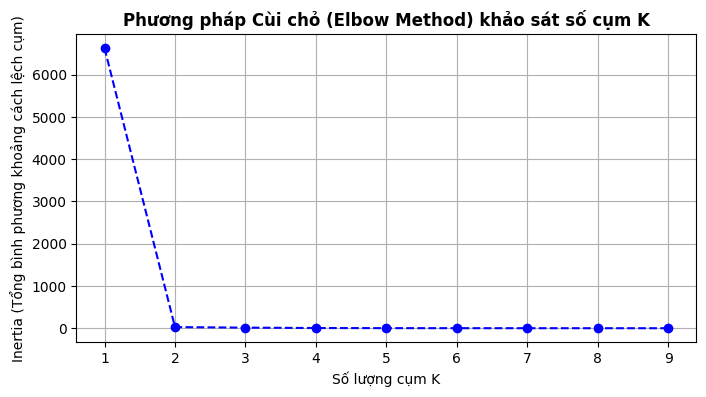

In [72]:
# PHƯƠNG PHÁP ĐƯỜNG CONG CÙI CHỎ (ELBOW METHOD)
# ==============================================================================
X = features_filtered[['GPA']].values
inertia = []
K = range(1, 10)

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, marker='o', color='b', linestyle='--')
plt.title("Phương pháp Cùi chỏ (Elbow Method) khảo sát số cụm K", fontsize=12, fontweight='bold')
plt.xlabel("Số lượng cụm K")
plt.ylabel("Inertia (Tổng bình phương khoảng cách lệch cụm)")
plt.grid(True)
plt.show()

In [73]:
# : PHÂN CỤM & TỰ ĐỘNG XẾP LOẠI HỌC LỰC

X = features_filtered[['GPA']].values

# Chạy thuật toán phân cụm thành 3 nhóm
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features_filtered['Cluster_Label'] = kmeans.fit_predict(X)

# Tìm giá trị trung bình GPA của từng cụm để sắp xếp thứ tự học lực chính xác
cluster_means = features_filtered.groupby('Cluster_Label')['GPA'].mean().sort_values()

# Ánh xạ nhãn tự động từ thấp đến cao
cluster_names = {
    cluster_means.index[0]: "Trung bình / Yếu",
    cluster_means.index[1]: "Khá",
    cluster_means.index[2]: "Giỏi / Xuất sắc"
}

features_filtered['Ten_Nhom_Cum'] = features_filtered['Cluster_Label'].map(cluster_names)

print("--- THỐNG KÊ SỐ LƯỢNG SINH VIÊN THEO CÁC PHÂN LỚP HỌC LỰC ---")
print(features_filtered['Ten_Nhom_Cum'].value_counts())

--- THỐNG KÊ SỐ LƯỢNG SINH VIÊN THEO CÁC PHÂN LỚP HỌC LỰC ---
Ten_Nhom_Cum
Trung bình / Yếu    39
Khá                 27
Giỏi / Xuất sắc      1
Name: count, dtype: int64


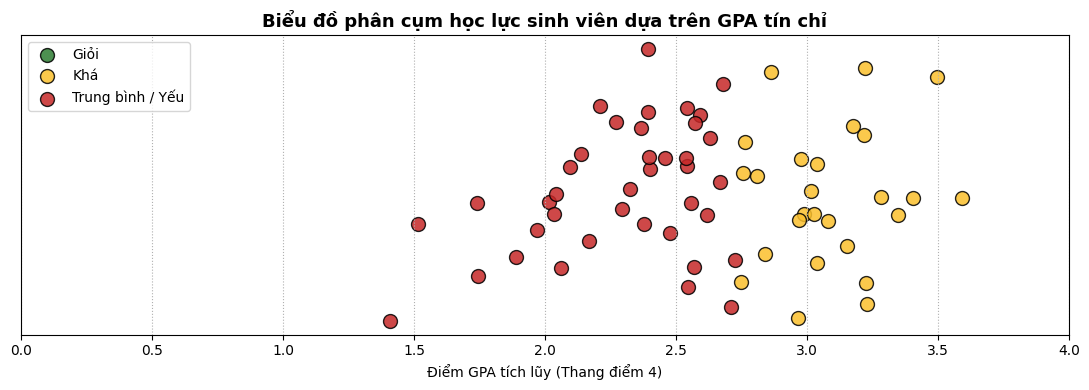

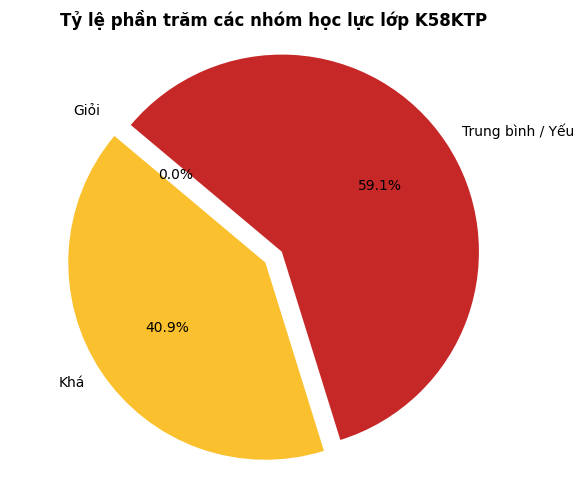

In [74]:
# VẼ BIỂU ĐỒ TRỰC QUAN HÓA KẾT QUẢ
# 1. Biểu đồ phân tán (Scatter Plot) phân cụm GPA kèm Jitter nhiễu để dễ nhìn điểm trùng
np.random.seed(42)
plt.figure(figsize=(11, 4))

colors_map = {"Giỏi": '#2E7D32', "Khá": '#FBC02D', "Trung bình / Yếu": '#C62828'}
groups = ["Giỏi", "Khá", "Trung bình / Yếu"]

for group_name in groups:
    sub_df = features_filtered[features_filtered['Ten_Nhom_Cum'] == group_name]
    y_jitter = np.random.normal(0, 0.05, size=len(sub_df)) # Tạo nhiễu trục Y để các chấm không đè lên nhau

    plt.scatter(
        sub_df['GPA'], y_jitter,
        c=colors_map[group_name], label=group_name,
        s=100, edgecolors='black', alpha=0.85
    )

plt.title('Biểu đồ phân cụm học lực sinh viên dựa trên GPA tín chỉ', fontsize=13, fontweight='bold')
plt.xlabel('Điểm GPA tích lũy (Thang điểm 4)')
plt.xlim(0.0, 4.0)
plt.gca().get_yaxis().set_visible(False) # Ẩn trục Y vì chỉ phân hóa theo trục X (GPA)
plt.grid(axis='x', linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Biểu đồ tròn (Pie Chart) thể hiện tỷ lệ phần trăm
counts = [features_filtered[features_filtered['Ten_Nhom_Cum'] == l].shape[0] for l in groups]

plt.figure(figsize=(6, 5))
plt.pie(counts, labels=groups, autopct='%1.1f%%', colors=[colors_map[g] for g in groups], startangle=140, explode=(0.05, 0.05, 0.05))
plt.title('Tỷ lệ phần trăm các nhóm học lực lớp K58KTP', fontsize=12, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [75]:
# SẮP XẾP VÀ XUẤT FILE BÁO CÁO (CSV & EXCEL)
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# Cấu hình độ ưu tiên để sắp xếp danh sách
priority_map = {"Giỏi": 0, "Khá": 1, "Trung bình / Yếu": 2}
features_filtered['Priority'] = features_filtered['Ten_Nhom_Cum'].map(priority_map)

# Sắp xếp: Nhóm Giỏi lên trước, trong từng nhóm ai GPA cao hơn đứng trước
features_filtered = features_filtered.sort_values(by=['Priority', 'GPA'], ascending=[True, False]).reset_index(drop=True)

# 1. Xuất file CSV dự phòng
features_filtered.to_csv("ket_qua_phan_cum_gpa.csv", index=False, encoding='utf-8-sig')

# 2. Tạo file Excel định dạng chuyên nghiệp bằng Openpyxl
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Phan Cum GPA"

# Khai báo style
HEADER_FILL = PatternFill(start_color="1F497D", end_color="1F497D", fill_type="solid")
FONT_HEADER = Font(bold=True, color="FFFFFF")
CENTER = Alignment(horizontal="center", vertical="center")
thin_border = Border(left=Side(style='thin', color='CCCCCC'),
                     right=Side(style='thin', color='CCCCCC'),
                     top=Side(style='thin', color='CCCCCC'),
                     bottom=Side(style='thin', color='CCCCCC'))

# Tiêu đề bảng
ws.merge_cells("A1:E1")
ws["A1"] = "DANH SÁCH PHÂN CỤM HỌC LỰC SINH VIÊN (GPA TÍN CHỈ)"
ws["A1"].font = Font(bold=True, size=14, color="1F497D")
ws["A1"].alignment = CENTER

# Headers cột
headers = ["STT", "MSSV", "Tên Sinh Viên", "GPA Tín Chỉ", "Nhóm Học Lực"]
for col, h in enumerate(headers, 1):
    cell = ws.cell(row=3, column=col, value=h)
    cell.fill = HEADER_FILL
    cell.font = FONT_HEADER
    cell.alignment = CENTER
    cell.border = thin_border

# Ghi dữ liệu vào file
for idx, row in features_filtered.iterrows():
    data_row = [idx + 1, row['MSSV'], row['Ten_SV'], round(row['GPA'], 2), row['Ten_Nhom_Cum']]
    for col, val in enumerate(data_row, 1):
        cell = ws.cell(row=idx + 4, column=col, value=val)
        cell.border = thin_border
        if col != 3: # Cột tên căn lề trái, các cột khác căn giữa
            cell.alignment = CENTER

# Thiết lập độ rộng cột tự động trực quan
ws.column_dimensions['A'].width = 8
ws.column_dimensions['B'].width = 18
ws.column_dimensions['C'].width = 30
ws.column_dimensions['D'].width = 15
ws.column_dimensions['E'].width = 25

# Lưu file kết quả tại thư mục hiện hành của Colab
output_file = "Ket_Qua_Phan_Cum_Moi.xlsx"
wb.save(output_file)

print(f"Xử lý thành công! Đã xuất các file báo cáo:\n1. 'ket_qua_phan_cum_gpa.csv'\n2. '{output_file}'")

Xử lý thành công! Đã xuất các file báo cáo:
1. 'ket_qua_phan_cum_gpa.csv'
2. 'Ket_Qua_Phan_Cum_Moi.xlsx'


In [76]:
from google.colab import files

files.download('ket_qua_phan_cum_gpa.csv')
files.download('Ket_Qua_Phan_Cum_Moi.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>